# Image Captioning — Data & Training
**Architecture:** BLIP (`Salesforce/blip-image-captioning-base`) fine-tuned on Flickr8k

This notebook takes a BLIP image-captioning model that was pre-trained on 129M
image-text pairs and fine-tunes it on Flickr8k so it produces captions in the
style of that dataset. End to end it:

1. Downloads the Flickr8k images and captions and loads them into a dataframe
   (5 human-written captions per image).
2. Loads the pretrained BLIP processor/model and splits the data into train
   and validation sets by image (so all 5 captions of a given image stay
   together on one side of the split).
3. Wraps the data in a `Dataset`/`DataLoader` that serves every (image,
   caption) pair each epoch, with light augmentation on the training images.
4. Fine-tunes BLIP with a partially-unfrozen vision encoder, a fully
   trainable text decoder, label smoothing, dropout regularisation, and a
   two-parameter-group optimizer (separate learning rates for the decoder
   and the unfrozen vision blocks) on a cosine LR schedule with warmup and
   early stopping.
5. Plots training curves, previews generated captions against references,
   scores the model with corpus BLEU-4 on the validation set, and saves the
   best checkpoint plus training history to disk.


## 0. Install Dependencies

In [29]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip("transformers>=4.35", "accelerate")
print("Dependencies ready.")


Dependencies ready.


## 1. Imports & Setup

In [30]:
import os, re, math, json, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import BlipProcessor, BlipForConditionalGeneration

os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


PyTorch: 2.10.0+cu128
CUDA available: True
Device: cuda


## 2. Data Loading

In [31]:
import kagglehub

dataset_path = kagglehub.dataset_download('giorgicheishvili/caption-data')
dataset_path = Path(dataset_path)
print("Dataset root:", dataset_path)


Dataset root: /kaggle/input/datasets/giorgicheishvili/caption-data


In [32]:
IMAGES_DIR    = dataset_path / "Images"
CAPTIONS_FILE = dataset_path / "captions.txt"

if not IMAGES_DIR.exists():
    candidates = list(dataset_path.rglob("Images"))
    IMAGES_DIR = candidates[0] if candidates else dataset_path
if not CAPTIONS_FILE.exists():
    candidates = list(dataset_path.rglob("captions.txt"))
    CAPTIONS_FILE = candidates[0]

print("Images dir :", IMAGES_DIR)
print("Captions   :", CAPTIONS_FILE)
print("Image count:", len(list(IMAGES_DIR.glob("*.jpg"))))


Images dir : /kaggle/input/datasets/giorgicheishvili/caption-data/Images
Captions   : /kaggle/input/datasets/giorgicheishvili/caption-data/captions.txt
Image count: 8091


In [33]:
df = pd.read_csv(CAPTIONS_FILE)
df.columns = [c.strip() for c in df.columns]
df['image']   = df['image'].str.strip()
df['caption'] = df['caption'].str.strip()

print(f"Total rows   : {len(df)}")
print(f"Unique images: {df['image'].nunique()}")
df.head(6)


Total rows   : 40455
Unique images: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting


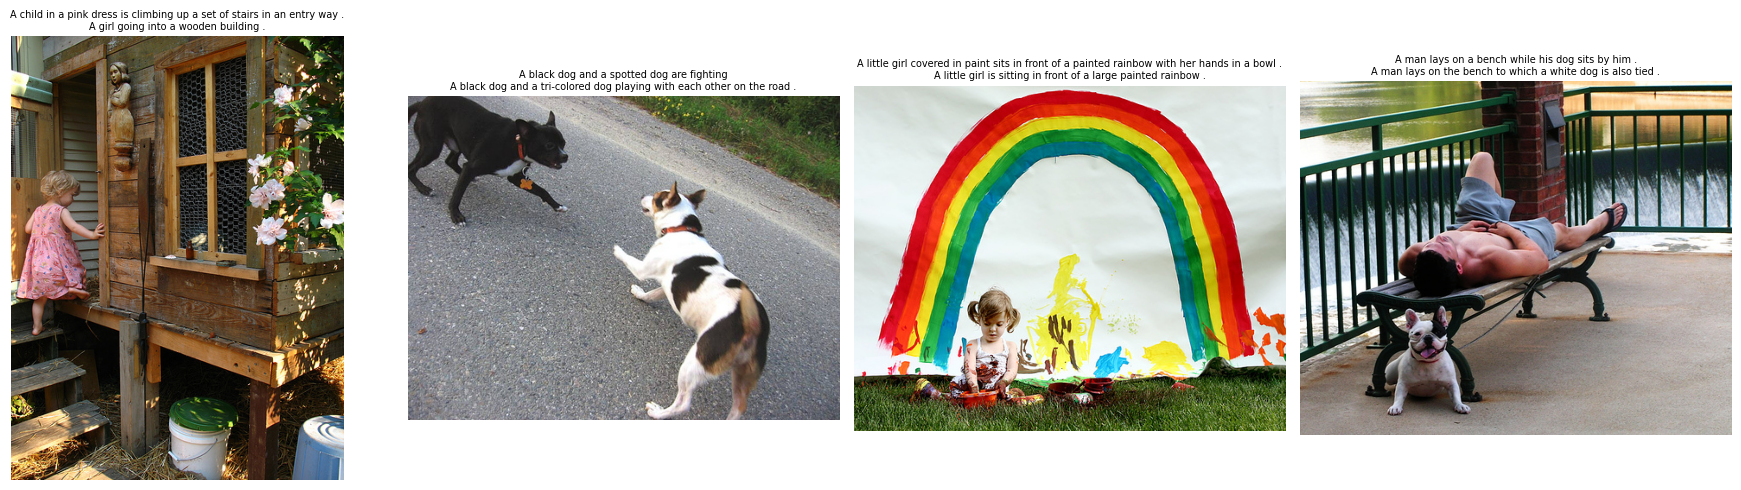

In [34]:
sample_imgs = df['image'].unique()[:4]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, img_name in zip(axes, sample_imgs):
    img      = Image.open(IMAGES_DIR / img_name).convert("RGB")
    captions = df[df['image'] == img_name]['caption'].tolist()
    ax.imshow(img)
    ax.set_title("\n".join(captions[:2]), fontsize=7, wrap=True)
    ax.axis('off')
plt.tight_layout(); plt.show()


## 3. Load BLIP Processor & Model

`Salesforce/blip-image-captioning-base` is pre-trained on 129M image-text pairs.  
The processor handles both image pre-processing and text tokenisation in one object.


In [35]:
MODEL_NAME = "Salesforce/blip-image-captioning-base"

processor = BlipProcessor.from_pretrained(MODEL_NAME)
model     = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model          : {MODEL_NAME}")
print(f"Total params   : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Model          : Salesforce/blip-image-captioning-base
Total params   : 247,444,600
Trainable params: 247,444,600


## 4. Train / Validation Split

In [36]:
all_images = df['image'].unique().tolist()
random.shuffle(all_images)

split      = int(0.90 * len(all_images))
train_imgs = set(all_images[:split])
val_imgs   = set(all_images[split:])

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_imgs)].reset_index(drop=True)

print(f"Train rows: {len(train_df)}  ({train_df['image'].nunique()} images)")
print(f"Val   rows: {len(val_df)}   ({val_df['image'].nunique()} images)")


Train rows: 36405  (7281 images)
Val   rows: 4050   (810 images)


## 5. Dataset & DataLoader

In [37]:
class FlickrDataset(Dataset):
    """
    Training: use ALL 5 captions per image every epoch, not just a random one.
    In v4 we sampled 1 caption per image → the model only saw 1/5 of the text
    signal per epoch. Using all 5 gives 5x more diverse caption-image pairs per
    epoch with zero extra compute cost on the vision side (same images).

    v7: training split now applies light augmentation (random horizontal flip +
    mild color jitter) so the model can't just memorize exact pixel patterns
    for an image across its 5 caption variants — this targets the overfitting
    onset we measured starting at epoch 4/5 in v6. Validation stays unaugmented.
    """
    def __init__(self, dataframe, images_dir, processor, augment=False):
        self.df         = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.processor  = processor
        self.augment    = augment
        if augment:
            from torchvision import transforms
            self.aug = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
            ])

    def __len__(self):
        return len(self.df)   # always use every row

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = row["image"]
        caption  = row["caption"]

        image = Image.open(self.images_dir / img_name).convert("RGB")
        if self.augment:
            image = self.aug(image)
        return image, caption


def collate_fn(batch):
    images, captions = zip(*batch)
    encoding = processor(
        images=list(images),
        text=list(captions),
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=64,
    )
    labels = encoding["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    encoding["labels"] = labels
    return encoding


BATCH_SIZE  = 16
NUM_WORKERS = 2

train_dataset = FlickrDataset(train_df, IMAGES_DIR, processor, augment=True)
val_dataset   = FlickrDataset(val_df,   IMAGES_DIR, processor, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print(f"Train batches : {len(train_loader)}  (5 captions × {train_df['image'].nunique()} images, augmented)")
print(f"Val   batches : {len(val_loader)}  (unaugmented)")


Train batches : 2276  (5 captions × 7281 images, augmented)
Val   batches : 254  (unaugmented)


## 6. Training

Fine-tunes BLIP end to end with the following setup:

- **Vision encoder mostly frozen** — only the last 2 ViT blocks
  (`vision_model.encoder.layers[-2:]`) are trainable, at a low learning rate
  (1e-6), so the model can adapt its visual features to Flickr8k without the
  cost or instability of retraining the full 86M-parameter vision tower.
- **Text decoder fully trainable** from epoch 1, at a higher learning rate
  (1e-5).
- **Two-parameter-group AdamW optimizer** so the decoder and the unfrozen
  vision blocks each get their own learning rate under a shared cosine decay
  schedule with linear warmup.
- **Label smoothing** (0.1) and **dropout** (p=0.2, applied via a forward
  hook on the decoder's last hidden layer) as regularisation.
- **Early stopping** on validation loss (patience=4) — the best checkpoint by
  val loss is saved to disk each time it improves.


In [38]:
ACCUM_STEPS     = 4
NUM_EPOCHS      = 15          
WARMUP_EPOCHS   = 1
PATIENCE        = 4
LABEL_SMOOTH    = 0.1
DECODER_DROPOUT = 0.2
DECODER_LR      = 1e-5
VISION_LR       = 1e-6       
N_VISION_LAYERS_UNFROZEN = 2 

# ── Freeze the whole vision encoder, then selectively unfreeze the last N blocks ──
for p in model.vision_model.parameters():
    p.requires_grad = False

vision_layers = model.vision_model.encoder.layers  # ModuleList of ViT blocks
for layer in vision_layers[-N_VISION_LAYERS_UNFROZEN:]:
    for p in layer.parameters():
        p.requires_grad = True

# Full text decoder trains
for p in model.text_decoder.parameters():
    p.requires_grad = True

# ── Regulariser: dropout on decoder hidden states ─────────────────────────────
# Hooks the final decoder layer's output before the prediction head and applies
# dropout. This directly fights overfitting by forcing the model not to rely
# on any single hidden unit too strongly.
dropout_layer = nn.Dropout(p=DECODER_DROPOUT)

def dropout_hook(module, input, output):
    if isinstance(output, tuple):
        return (dropout_layer(output[0]),) + output[1:]
    return dropout_layer(output)

# Attach to the last BERT layer of the text decoder
_hook_handle = model.text_decoder.bert.encoder.layer[-1].register_forward_hook(dropout_hook)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
vision_trainable = sum(p.numel() for layer in vision_layers[-N_VISION_LAYERS_UNFROZEN:]
                        for p in layer.parameters())
print(f"Trainable params         : {trainable:,}")
print(f"Frozen params            : {frozen:,}")
print(f"  of which vision-tower trainable (last {N_VISION_LAYERS_UNFROZEN} blocks): {vision_trainable:,}")
print(f"Decoder dropout          : {DECODER_DROPOUT}")

# ── Two parameter groups: decoder (lr=1e-5) and unfrozen vision blocks (lr=1e-6) ──
# Deduplicate params (BLIP has tied weights) while splitting by group.
seen = set()
decoder_params, vision_params = [], []
vision_param_ids = {id(p) for layer in vision_layers[-N_VISION_LAYERS_UNFROZEN:]
                     for p in layer.parameters()}

for p in model.parameters():
    if not p.requires_grad or id(p) in seen:
        continue
    seen.add(id(p))
    if id(p) in vision_param_ids:
        vision_params.append(p)
    else:
        decoder_params.append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": decoder_params, "lr": DECODER_LR},
        {"params": vision_params,  "lr": VISION_LR},
    ],
    weight_decay=1e-2,
    betas=(0.9, 0.98),
)

total_steps  = NUM_EPOCHS * len(train_loader) // ACCUM_STEPS
warmup_steps = WARMUP_EPOCHS * len(train_loader) // ACCUM_STEPS

# Cosine decay over the recalibrated 8-epoch schedule — no restarts.
# Same LR *shape* (fraction of base LR) applies to both param groups since
# LambdaLR multiplies each group's own base lr by the same lambda each step.
def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.amp.GradScaler("cuda")

print(f"Total update steps : {total_steps}")
print(f"Warmup steps       : {warmup_steps}")
print(f"Label smoothing    : {LABEL_SMOOTH}")
print(f"Decoder LR / Vision LR : {DECODER_LR} / {VISION_LR}")


Trainable params         : 175,529,848
Frozen params            : 71,914,752
  of which vision-tower trainable (last 2 blocks): 14,175,744
Decoder dropout          : 0.2
Total update steps : 8535
Warmup steps       : 569
Label smoothing    : 0.1
Decoder LR / Vision LR : 1e-05 / 1e-06


In [39]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*lr_scheduler.*")


def smooth_loss(logits, labels, smoothing=0.1, ignore_index=-100):
    """Cross-entropy with label smoothing."""
    vocab_size   = logits.size(-1)
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()
    mask         = (shift_labels != ignore_index)
    log_probs    = torch.nn.functional.log_softmax(shift_logits, dim=-1)
    nll          = -log_probs.gather(dim=-1, index=shift_labels.clamp(min=0).unsqueeze(-1)).squeeze(-1)
    smooth       = -log_probs.sum(dim=-1) / vocab_size
    loss         = (1 - smoothing) * nll + smoothing * smooth
    return loss[mask].mean()


def train_one_epoch(model, loader, optimizer, scheduler, scaler, device, accum_steps):
    model.train()   # dropout hook is active in train mode
    total_loss, n_batches        = 0.0, 0
    correct_tokens, total_tokens = 0, 0
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

        with torch.amp.autocast("cuda"):
            outputs = model(**batch)
            loss    = smooth_loss(outputs.logits, batch["labels"],
                                  smoothing=LABEL_SMOOTH) / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        with torch.no_grad():
            shift_logits = outputs.logits[:, :-1, :].contiguous()
            shift_labels = batch["labels"][:, 1:].contiguous()
            preds = shift_logits.argmax(dim=-1)
            mask  = (shift_labels != -100)
            correct_tokens += (preds[mask] == shift_labels[mask]).sum().item()
            total_tokens   += mask.sum().item()
            total_loss     += loss.item() * accum_steps
            n_batches      += 1

    optimizer.zero_grad()
    return total_loss / max(n_batches, 1), correct_tokens / max(total_tokens, 1)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()   # dropout hook becomes a no-op in eval mode
    total_loss, n_batches        = 0.0, 0
    correct_tokens, total_tokens = 0, 0

    for batch in loader:
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        with torch.amp.autocast("cuda"):
            outputs = model(**batch)
            loss    = smooth_loss(outputs.logits, batch["labels"], smoothing=LABEL_SMOOTH)

        shift_logits = outputs.logits[:, :-1, :].contiguous()
        shift_labels = batch["labels"][:, 1:].contiguous()
        preds = shift_logits.argmax(dim=-1)
        mask  = (shift_labels != -100)
        correct_tokens += (preds[mask] == shift_labels[mask]).sum().item()
        total_tokens   += mask.sum().item()
        total_loss     += loss.item()
        n_batches      += 1

    return total_loss / n_batches, correct_tokens / max(total_tokens, 1)


In [40]:
SAVE_DIR = Path("/kaggle/working")
SAVE_DIR.mkdir(exist_ok=True)

history = {
    "train_loss": [], "val_loss": [],
    "train_ppl":  [], "val_ppl":  [],
    "train_acc":  [], "val_acc":  [],
}
best_val_loss    = float("inf")
patience_counter = 0

print(
    f"{'Epoch':>6}  {'Tr Loss':>8}  {'Tr PPL':>7}  {'Tr Acc':>7}  "
    f"{'Val Loss':>9}  {'Val PPL':>8}  {'Val Acc':>8}  {'Time':>6}"
)
print("-" * 85)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, DEVICE, ACCUM_STEPS
    )
    val_loss, val_acc = evaluate(model, val_loader, DEVICE)

    train_ppl = math.exp(min(train_loss, 20))
    val_ppl   = math.exp(min(val_loss,   20))
    elapsed   = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ppl"].append(train_ppl)
    history["val_ppl"].append(val_ppl)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"{epoch:>6}  {train_loss:>8.4f}  {train_ppl:>7.2f}  {train_acc:>6.2%}  "
          f"{val_loss:>9.4f}  {val_ppl:>8.2f}  {val_acc:>7.2%}  {elapsed:>5.0f}s")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        model.save_pretrained(str(SAVE_DIR / "best_model"))
        processor.save_pretrained(str(SAVE_DIR / "best_model"))
        print(f"         ✓ New best saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print("\nTraining complete.")
print(f"Best val loss : {best_val_loss:.4f}  |  Best val PPL: {math.exp(min(best_val_loss,20)):.2f}")


 Epoch   Tr Loss   Tr PPL   Tr Acc   Val Loss   Val PPL   Val Acc    Time
-------------------------------------------------------------------------------------
     1    3.7811    43.87  47.35%     3.3805     29.39   49.25%   1153s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=3.3805)
     2    3.1189    22.62  54.49%     3.0892     21.96   54.76%   1152s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=3.0892)
     3    2.9751    19.59  56.92%     3.0634     21.40   55.22%   1154s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=3.0634)
     4    2.9056    18.28  58.05%     3.0567     21.26   55.39%   1154s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=3.0567)
     5    2.8486    17.26  59.21%     3.0603     21.33   55.29%   1153s
     6    2.7979    16.41  60.16%     3.0590     21.31   55.27%   1154s
     7    2.7539    15.70  61.11%     3.0698     21.54   55.34%   1153s
     8    2.7149    15.10  62.01%     3.0797     21.75   55.17%   1153s

Early stopping at epoch 8.

Training complete.
Best val loss : 3.0567  |  Best val PPL: 21.26


## 7. Training Curves

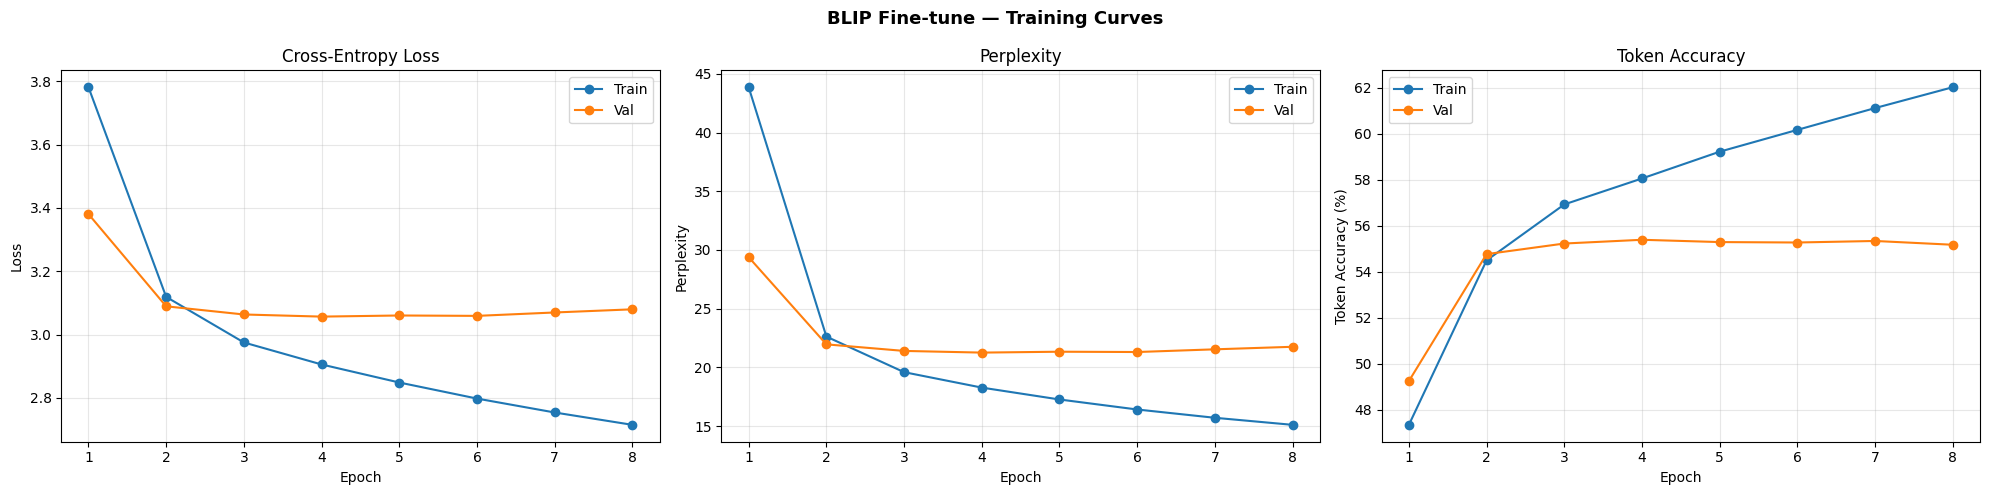

In [41]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val",   marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Cross-Entropy Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history["train_ppl"], label="Train", marker="o")
axes[1].plot(epochs_ran, history["val_ppl"],   label="Val",   marker="o")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_ran, [a * 100 for a in history["train_acc"]], label="Train", marker="o")
axes[2].plot(epochs_ran, [a * 100 for a in history["val_acc"]],   label="Val",   marker="o")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Token Accuracy (%)")
axes[2].set_title("Token Accuracy"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("BLIP Fine-tune — Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Caption Preview

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


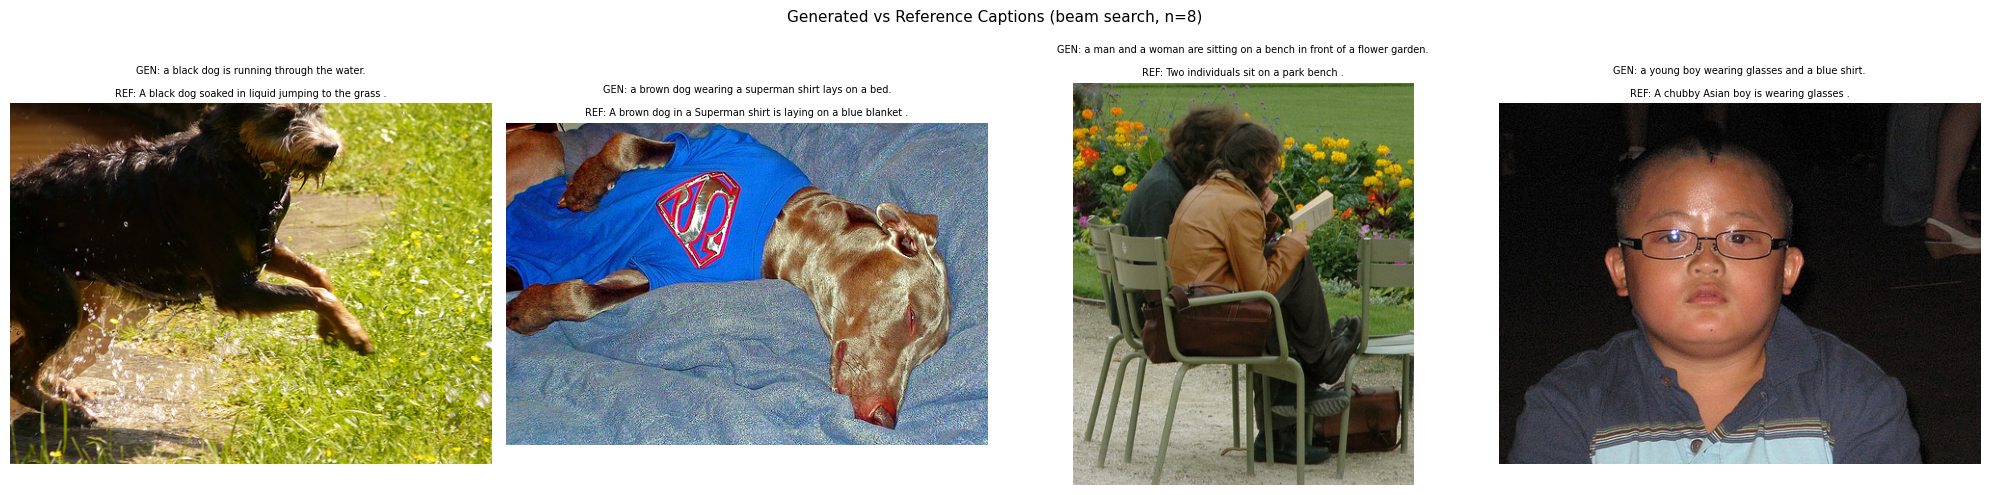

In [42]:
from transformers import BlipForConditionalGeneration as _BLIP

best_model     = _BLIP.from_pretrained(str(SAVE_DIR / 'best_model')).to(DEVICE)
best_processor = BlipProcessor.from_pretrained(str(SAVE_DIR / 'best_model'))
best_model.eval()

@torch.no_grad()
def generate_caption(image_path: str, model=best_model) -> str:
    """
    Takes a path to an image and returns a generated caption string.
    """
    image   = Image.open(image_path).convert("RGB")
    inputs  = best_processor(images=image, return_tensors="pt").to(DEVICE)
    out_ids = model.generate(**inputs, max_new_tokens=40, num_beams=8)
    return best_processor.decode(out_ids[0], skip_special_tokens=True)


sample_rows = val_df.drop_duplicates('image').sample(4, random_state=SEED)
fig, axes   = plt.subplots(1, 4, figsize=(20, 5))

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = str(IMAGES_DIR / row['image'])
    caption  = generate_caption(img_path)
    ref_caps = val_df[val_df['image'] == row['image']]['caption'].tolist()

    ax.imshow(Image.open(img_path))
    ax.set_title(f"GEN: {caption}\n\nREF: {ref_caps[0]}", fontsize=7, wrap=True)
    ax.axis('off')

plt.suptitle('Generated vs Reference Captions (beam search, n=8)', fontsize=11)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'caption_examples.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. BLEU-4 Evaluation

Compute BLEU-4 on the validation set — the standard metric for captioning on Flickr8k.  
Each generated caption is compared against all 5 human references for that image.


In [43]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nltk"])
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

best_model.eval()
val_images = val_df['image'].unique().tolist()

all_references = []
all_hypotheses = []

print(f"Evaluating BLEU-4 on {len(val_images)} validation images...")

for i, img_name in enumerate(val_images):
    img_path = str(IMAGES_DIR / img_name)
    caption  = generate_caption(img_path)

    refs = val_df[val_df['image'] == img_name]['caption'].tolist()
    ref_tokens  = [r.lower().split() for r in refs]
    hyp_tokens  = caption.lower().split()

    all_references.append(ref_tokens)
    all_hypotheses.append(hyp_tokens)

    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(val_images)} done...")

smoother = SmoothingFunction().method1
bleu4 = corpus_bleu(all_references, all_hypotheses,
                    weights=(0.25, 0.25, 0.25, 0.25),
                    smoothing_function=smoother)

print(f"\nBLEU-4 on validation set: {bleu4 * 100:.2f}")


Evaluating BLEU-4 on 810 validation images...
  100/810 done...
  200/810 done...
  300/810 done...
  400/810 done...
  500/810 done...
  600/810 done...
  700/810 done...
  800/810 done...

BLEU-4 on validation set: 31.40


## 10. Save Artifacts

In [44]:
with open(SAVE_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f)

print("Artifacts in:", SAVE_DIR)
print("  best_model/            — BLIP weights + processor (use with from_pretrained)")
print("  training_curves.png    — loss & perplexity plots")
print("  caption_examples.png   — sample generated captions")
print("  training_history.json  — per-epoch metrics")


Artifacts in: /kaggle/working
  best_model/            — BLIP weights + processor (use with from_pretrained)
  training_curves.png    — loss & perplexity plots
  caption_examples.png   — sample generated captions
  training_history.json  — per-epoch metrics
